In [ ]:
!pip install pandas numpy matplotlib seaborn scipy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


plt.style.use('default')  
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)

print("=== Lab 1. Анализ датасета Wine Quality ===")

=== Lab 1. Анализ датасета Wine Quality ===


In [15]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine_data = pd.read_csv(url, sep=';')

print("1. ОСНОВНАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ")
print("="*50)


print(f"Размер датасета: {wine_data.shape}")
print(f"Количество строк: {wine_data.shape[0]}")
print(f"Количество столбцов: {wine_data.shape[1]}")
print("\nПервые 5 строк датасета:")
display(wine_data.head())

1. ОСНОВНАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ
Размер датасета: (1599, 12)
Количество строк: 1599
Количество столбцов: 12

Первые 5 строк датасета:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [16]:
print("\n2. ОПИСАНИЕ ДАТАСЕТА")
print("="*50)

description = """
ПРЕДМЕТНАЯ ОБЛАСТЬ:
• Качество вин на основе физико-химических свойств
• Данные используются для предсказания качества вина по его химическим характеристикам

ИСТОЧНИК ДАННЫХ:
• UCI Machine Learning Repository
• Original source: P. Cortez, A. Cerdeira, F. Almeida, T. Matos and J. Reis

ХАРАКТЕР ДАННЫХ:
• Реальные данные о красных винах сорта "Vinho Verde" из Португалии

ЗАДАЧА АНАЛИЗА:
• Классификация: предсказание качества вина (оценка от 0 до 10)
• Регрессия: предсказание числовой оценки качества
• Кластеризация: группировка вин по схожим характеристикам
"""

print(description)


2. ОПИСАНИЕ ДАТАСЕТА

ПРЕДМЕТНАЯ ОБЛАСТЬ:
• Качество вин на основе физико-химических свойств
• Данные используются для предсказания качества вина по его химическим характеристикам

ИСТОЧНИК ДАННЫХ:
• UCI Machine Learning Repository
• Original source: P. Cortez, A. Cerdeira, F. Almeida, T. Matos and J. Reis

ХАРАКТЕР ДАННЫХ:
• Реальные данные о красных винах сорта "Vinho Verde" из Португалии

ЗАДАЧА АНАЛИЗА:
• Классификация: предсказание качества вина (оценка от 0 до 10)
• Регрессия: предсказание числовой оценки качества
• Кластеризация: группировка вин по схожим характеристикам



In [17]:
print("\nОПИСАНИЕ АТРИБУТОВ:")
print("-" * 30)

attributes_info = {
    'fixed acidity': ['Числовой', 'Непосредственная кислотность (г/л)'],
    'volatile acidity': ['Числовой', 'Летучая кислотность (г/л)'],
    'citric acid': ['Числовой', 'Содержание лимонной кислоты (г/л)'],
    'residual sugar': ['Числовой', 'Остаточный сахар (г/л)'],
    'chlorides': ['Числовой', 'Содержание хлоридов (г/л)'],
    'free sulfur dioxide': ['Числовой', 'Свободный диоксид серы (мг/л)'],
    'total sulfur dioxide': ['Числовой', 'Общий диоксид серы (мг/л)'],
    'density': ['Числовой', 'Плотность (г/мл)'],
    'pH': ['Числовой', 'Уровень pH'],
    'sulphates': ['Числовой', 'Содержание сульфатов (г/л)'],
    'alcohol': ['Числовой', 'Содержание алкоголя (%)'],
    'quality': ['Целочисленный', 'Качество вина (оценка от 0 до 10)']
}

for attr, info in attributes_info.items():
    print(f"{attr:25} | {info[0]:15} | {info[1]}")


ОПИСАНИЕ АТРИБУТОВ:
------------------------------
fixed acidity             | Числовой        | Непосредственная кислотность (г/л)
volatile acidity          | Числовой        | Летучая кислотность (г/л)
citric acid               | Числовой        | Содержание лимонной кислоты (г/л)
residual sugar            | Числовой        | Остаточный сахар (г/л)
chlorides                 | Числовой        | Содержание хлоридов (г/л)
free sulfur dioxide       | Числовой        | Свободный диоксид серы (мг/л)
total sulfur dioxide      | Числовой        | Общий диоксид серы (мг/л)
density                   | Числовой        | Плотность (г/мл)
pH                        | Числовой        | Уровень pH
sulphates                 | Числовой        | Содержание сульфатов (г/л)
alcohol                   | Числовой        | Содержание алкоголя (%)
quality                   | Целочисленный   | Качество вина (оценка от 0 до 10)


In [18]:
print("\n3. СТАТИСТИЧЕСКИЙ АНАЛИЗ АТРИБУТОВ")
print("="*50)

print("БАЗОВАЯ СТАТИСТИКА:")
display(wine_data.describe())


3. СТАТИСТИЧЕСКИЙ АНАЛИЗ АТРИБУТОВ
БАЗОВАЯ СТАТИСТИКА:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [19]:
print("\nПРОВЕРКА ПРОПУЩЕННЫХ ЗНАЧЕНИЙ:")
missing_data = wine_data.isnull().sum()
missing_percent = (wine_data.isnull().sum() / len(wine_data)) * 100

missing_info = pd.DataFrame({
    'Пропущенные значения': missing_data,
    'Процент пропусков': missing_percent
})
display(missing_info)

print(f"Вывод: Пропущенные значения {'обнаружены' if missing_data.any() else 'не обнаружены'}")


ПРОВЕРКА ПРОПУЩЕННЫХ ЗНАЧЕНИЙ:


,Пропущенные значения,Процент пропусков
fixed acidity,0,0.0
volatile acidity,0,0.0
citric acid,0,0.0
residual sugar,0,0.0
chlorides,0,0.0
free sulfur dioxide,0,0.0
total sulfur dioxide,0,0.0
density,0,0.0
pH,0,0.0
sulphates,0,0.0


Вывод: Пропущенные значения не обнаружены


In [20]:
print("\nДЕТАЛЬНЫЙ СТАТИСТИЧЕСКИЙ АНАЛИЗ:")
print("-" * 50)

stats_results = []
for column in wine_data.columns:
    col_data = wine_data[column]
    stats_dict = {
        'Атрибут': column,
        'Среднее': np.mean(col_data),
        'Среднее квадратическое отклонение': np.std(col_data),
        'Минимум': np.min(col_data),
        'Максимум': np.max(col_data),
        'Количество выбросов': len(col_data[(np.abs(stats.zscore(col_data)) > 3)])
    }
    stats_results.append(stats_dict)

stats_df = pd.DataFrame(stats_results)
display(stats_df.round(3))


ДЕТАЛЬНЫЙ СТАТИСТИЧЕСКИЙ АНАЛИЗ:
--------------------------------------------------


,Атрибут,Среднее,Среднее квадратическое отклонение,Минимум,Максимум,Количество выбросов
0,fixed acidity,8.320,1.741,4.600,15.900,12
1,volatile acidity,0.528,0.179,0.120,1.580,10
2,citric acid,0.271,0.195,0.000,1.000,1
3,residual sugar,2.539,1.409,0.900,15.500,30
4,chlorides,0.087,0.047,0.012,0.611,31
5,free sulfur dioxide,15.875,10.457,1.000,72.000,22
6,total sulfur dioxide,46.468,32.885,6.000,289.000,15
7,density,0.997,0.002,0.990,1.004,18
8,pH,3.311,0.154,2.740,4.010,8
9,sulphates,0.658,0.169,0.330,2.000,27



ГИСТОГРАММЫ РАСПРЕДЕЛЕНИЯ ЗНАЧЕНИЙ:


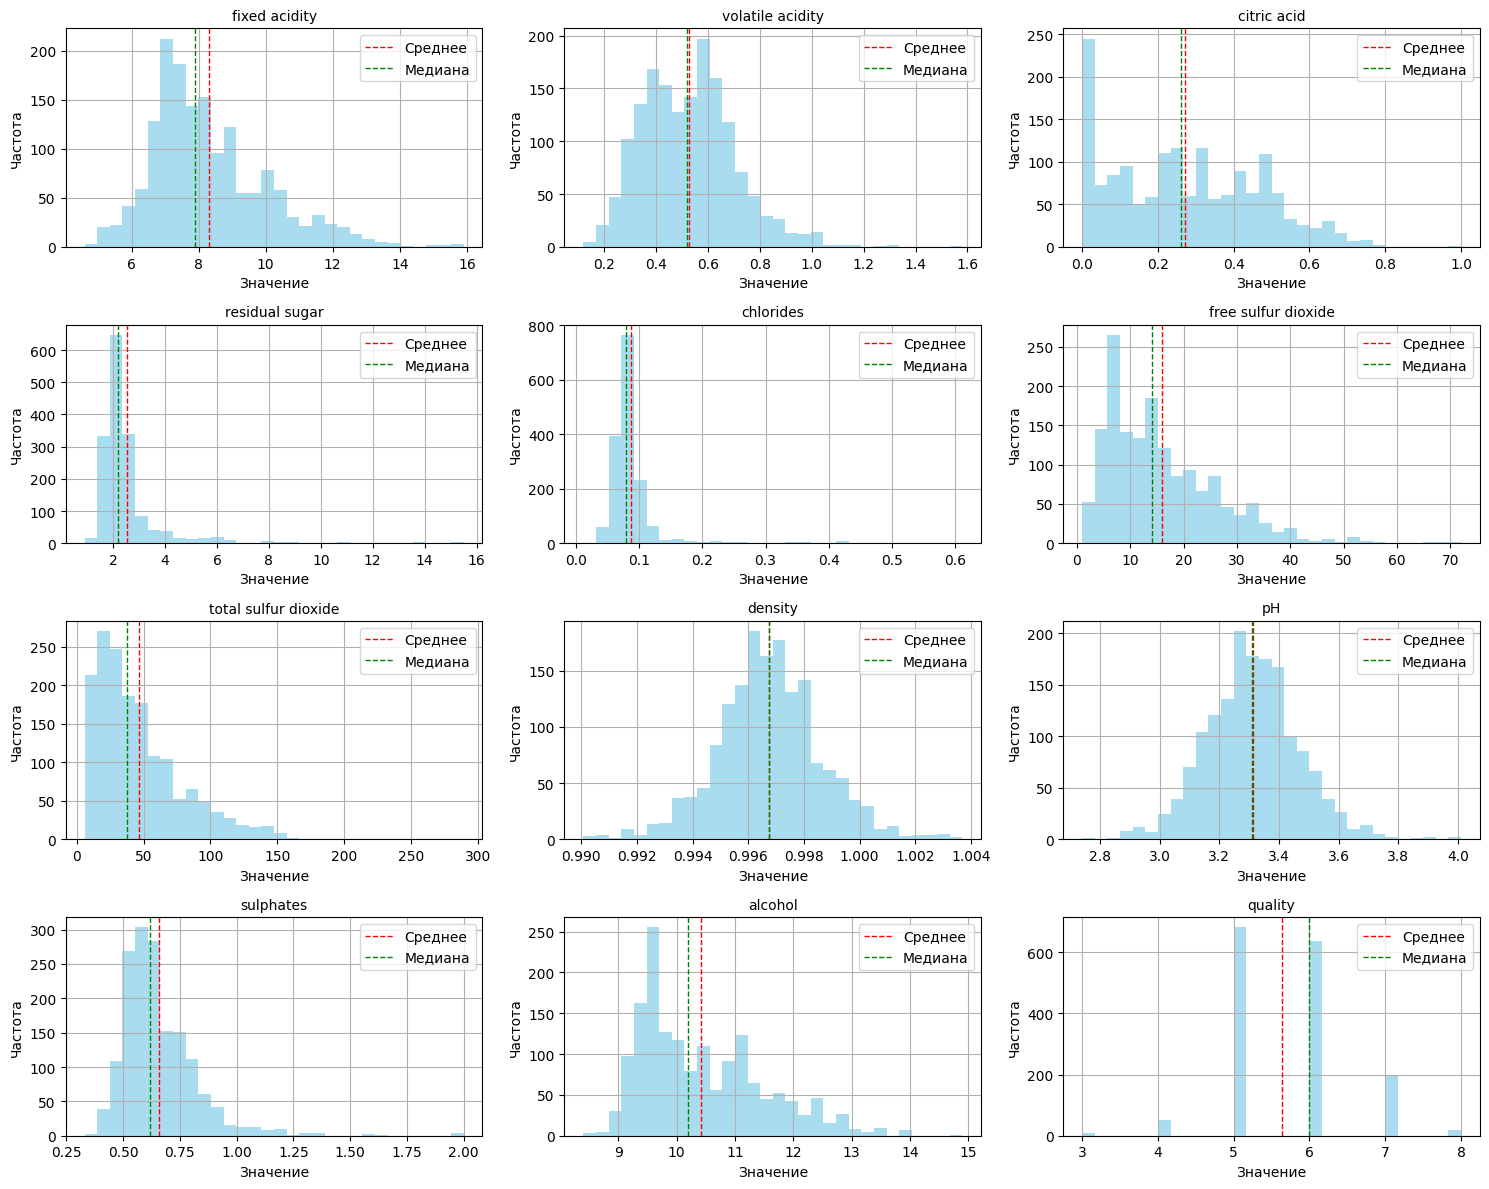

АНАЛИЗ ВЫБРОСОВ:
Выбросы определяются как значения, отстоящие от среднего более чем на 3 стандартных отклонения


In [21]:
print("\nГИСТОГРАММЫ РАСПРЕДЕЛЕНИЯ ЗНАЧЕНИЙ:")
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.ravel()

for i, column in enumerate(wine_data.columns):
    wine_data[column].hist(bins=30, ax=axes[i], alpha=0.7, color='skyblue')
    axes[i].axvline(wine_data[column].mean(), color='red', linestyle='--', linewidth=1, label='Среднее')
    axes[i].axvline(wine_data[column].median(), color='green', linestyle='--', linewidth=1, label='Медиана')
    axes[i].set_title(f'{column}', fontsize=10)
    axes[i].set_xlabel('Значение')
    axes[i].set_ylabel('Частота')
    axes[i].legend()

plt.tight_layout()
plt.show()

print("АНАЛИЗ ВЫБРОСОВ:")
print("Выбросы определяются как значения, отстоящие от среднего более чем на 3 стандартных отклонения")


АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (QUALITY):


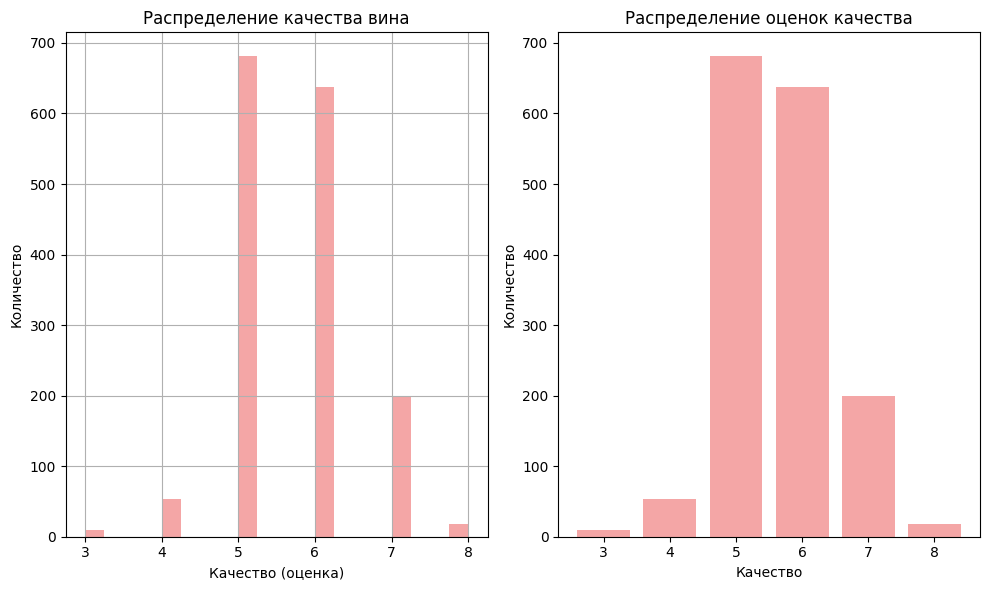

Диапазон оценок качества: от 3 до 8
Наиболее частая оценка: 5


In [22]:
print("\nАНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (QUALITY):")
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
wine_data['quality'].hist(bins=20, alpha=0.7, color='lightcoral')
plt.title('Распределение качества вина')
plt.xlabel('Качество (оценка)')
plt.ylabel('Количество')

plt.subplot(1, 2, 2)
quality_counts = wine_data['quality'].value_counts().sort_index()
plt.bar(quality_counts.index, quality_counts.values, color='lightcoral', alpha=0.7)
plt.title('Распределение оценок качества')
plt.xlabel('Качество')
plt.ylabel('Количество')

plt.tight_layout()
plt.show()

print(f"Диапазон оценок качества: от {wine_data['quality'].min()} до {wine_data['quality'].max()}")
print(f"Наиболее частая оценка: {wine_data['quality'].mode().values[0]}")


4. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ


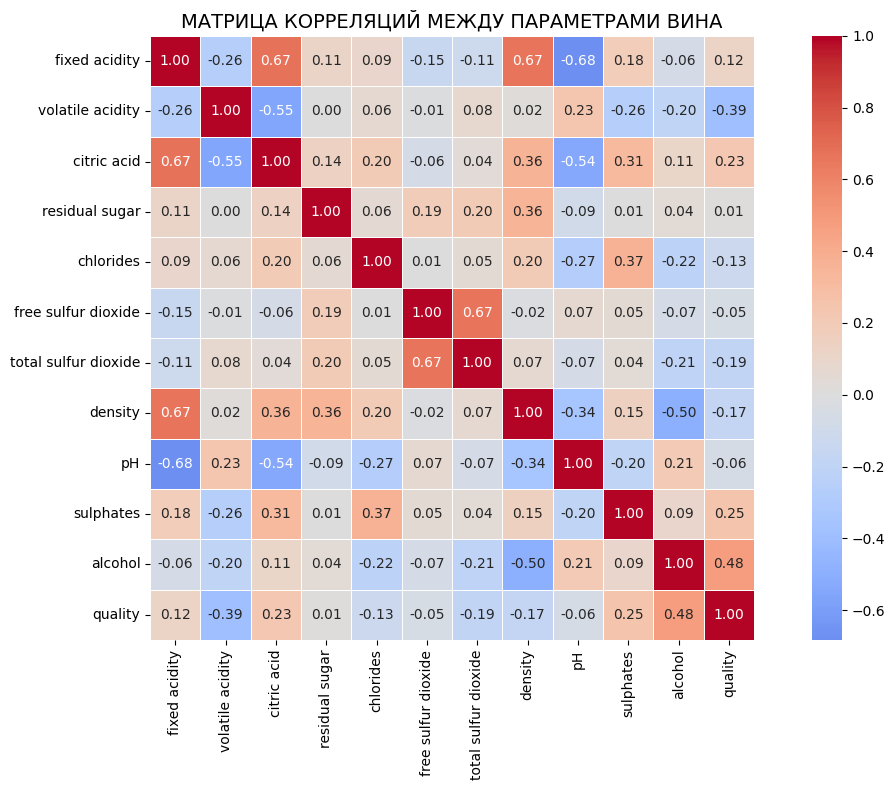

In [23]:
print("\n4. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ")
print("="*50)

correlation_matrix = wine_data.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, fmt='.2f')
plt.title('МАТРИЦА КОРРЕЛЯЦИЙ МЕЖДУ ПАРАМЕТРАМИ ВИНА', fontsize=14)
plt.tight_layout()
plt.show()


КОРРЕЛЯЦИИ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (QUALITY):


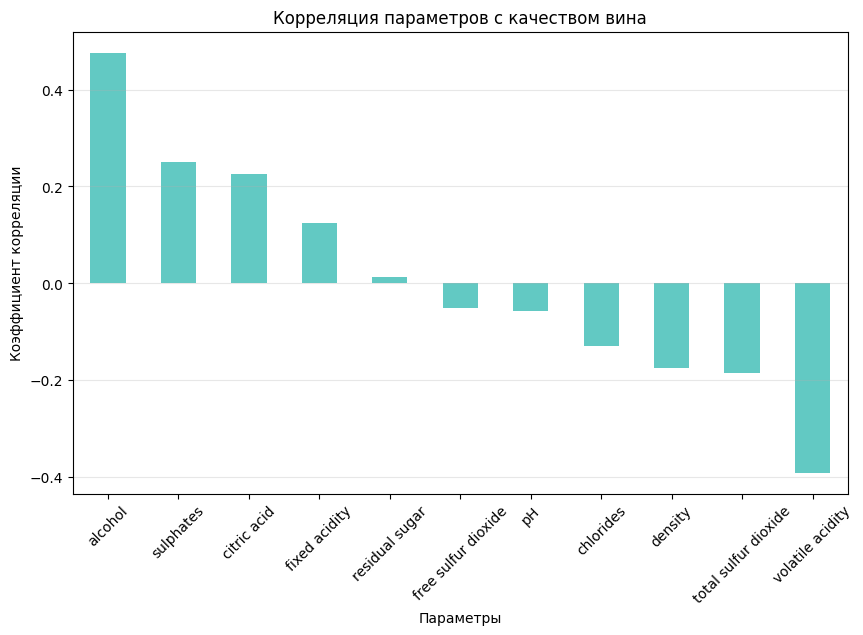

Наиболее значимые корреляции с качеством:
alcohol              |  0.476 | положительная
sulphates            |  0.251 | положительная
citric acid          |  0.226 | положительная
fixed acidity        |  0.124 | положительная
residual sugar       |  0.014 | положительная
free sulfur dioxide  | -0.051 | отрицательная
pH                   | -0.058 | отрицательная
chlorides            | -0.129 | отрицательная
density              | -0.175 | отрицательная
total sulfur dioxide | -0.185 | отрицательная
volatile acidity     | -0.391 | отрицательная


In [24]:
print("\nКОРРЕЛЯЦИИ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (QUALITY):")
quality_corr = correlation_matrix['quality'].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
quality_corr.drop('quality').plot(kind='bar', color='lightseagreen', alpha=0.7)
plt.title('Корреляция параметров с качеством вина')
plt.xlabel('Параметры')
plt.ylabel('Коэффициент корреляции')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

print("Наиболее значимые корреляции с качеством:")
for param, corr in quality_corr.items():
    if param != 'quality':
        correlation_type = "положительная" if corr > 0 else "отрицательная"
        print(f"{param:20} | {corr:6.3f} | {correlation_type}")


МАТРИЦА ГРАФИКОВ РАССЕИВАНИЯ:


<Figure size 1200x1000 with 0 Axes>

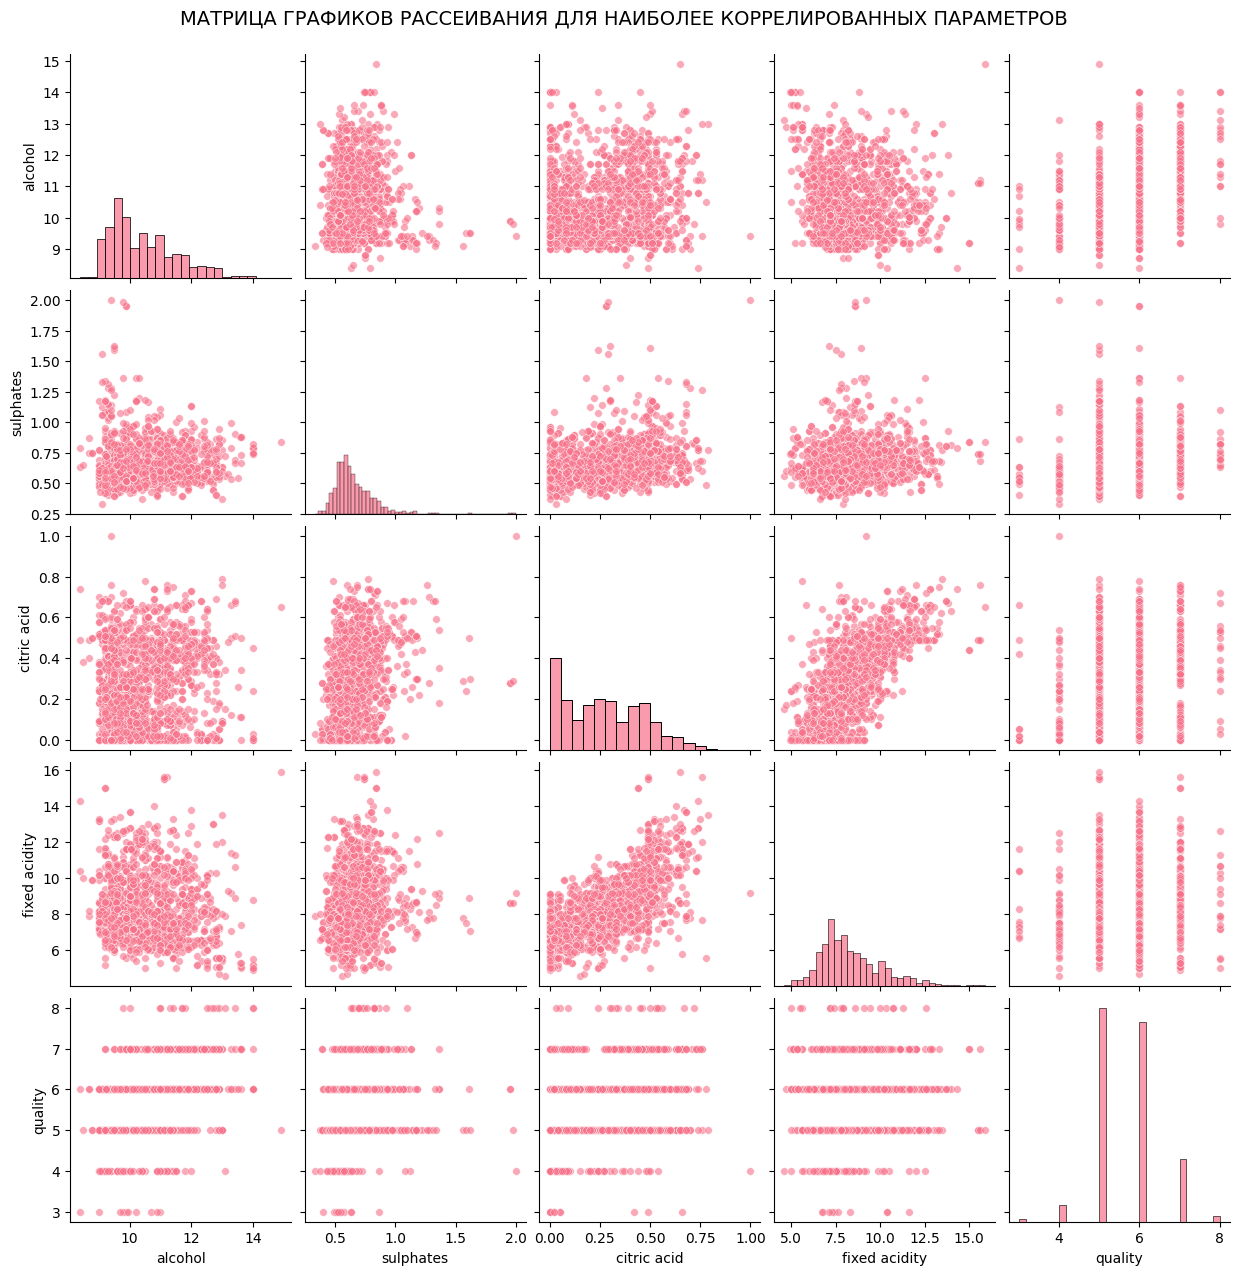

In [25]:
print("\nМАТРИЦА ГРАФИКОВ РАССЕИВАНИЯ:")

top_features = quality_corr.drop('quality').head(4).index.tolist()
selected_features = top_features + ['quality']

plt.figure(figsize=(12, 10))
sns.pairplot(wine_data[selected_features], diag_kind='hist', 
             plot_kws={'alpha': 0.6, 's': 30}, 
             diag_kws={'alpha': 0.7})
plt.suptitle('МАТРИЦА ГРАФИКОВ РАССЕИВАНИЯ ДЛЯ НАИБОЛЕЕ КОРРЕЛИРОВАННЫХ ПАРАМЕТРОВ', 
             y=1.02, fontsize=14)
plt.show()

In [26]:
print("\nАНАЛИЗ ВЫСОКОКОРРЕЛИРОВАННЫХ ПАРАМЕТРОВ:")
print("-" * 50)

high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.5:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

print("Пары параметров с высокой корреляцией (|r| > 0.5):")
for param1, param2, corr in high_corr_pairs:
    corr_type = "положительная" if corr > 0 else "отрицательная"
    print(f"{param1:20} ↔ {param2:20} | {corr:6.3f} | {corr_type}")

print("\nПАРАМЕТРЫ С НИЗКОЙ КОРРЕЛЯЦИЕЙ:")
low_corr_features = []
for feature in wine_data.columns:
    if feature != 'quality':
        max_corr = correlation_matrix[feature].drop(feature).abs().max()
        if max_corr < 0.3:
            low_corr_features.append((feature, max_corr))

for feature, max_corr in low_corr_features:
    print(f"{feature:20} | максимальная корреляция: {max_corr:.3f}")


АНАЛИЗ ВЫСОКОКОРРЕЛИРОВАННЫХ ПАРАМЕТРОВ:
--------------------------------------------------
Пары параметров с высокой корреляцией (|r| > 0.5):
fixed acidity        ↔ pH                   | -0.683 | отрицательная
fixed acidity        ↔ citric acid          |  0.672 | положительная
fixed acidity        ↔ density              |  0.668 | положительная
free sulfur dioxide  ↔ total sulfur dioxide |  0.668 | положительная
volatile acidity     ↔ citric acid          | -0.552 | отрицательная
citric acid          ↔ pH                   | -0.542 | отрицательная

ПАРАМЕТРЫ С НИЗКОЙ КОРРЕЛЯЦИЕЙ:


In [27]:
print("\n5. ВЫВОДЫ И РЕЗУЛЬТАТЫ АНАЛИЗА")
print("="*50)

conclusions = """
ОСНОВНЫЕ ВЫВОДЫ:

1. КАЧЕСТВО ДАННЫХ:
   • Пропущенные значения отсутствуют
   • Все данные числовые

2. СТАТИСТИЧЕСКИЕ ОСОБЕННОСТИ:
   • Большинство параметров имеют нормальное или близкое к нормальному распределение
   • Обнаружены выбросы в параметрах: residual sugar, chlorides, free sulfur dioxide
   • Качество вина распределено в диапазоне 3-8 баллов, наиболее частые оценки 5-6

3. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ:
   • Наибольшее влияние на качество: alcohol (положительная), volatile acidity (отрицательная)
   • Сильные корреляции между химическими параметрами: 
        - fixed acidity и density
        - free sulfur dioxide и total sulfur dioxide
        - fixed acidity и pH (отрицательная)

4. РЕКОМЕНДАЦИИ ДЛЯ ДАЛЬНЕЙШЕГО АНАЛИЗА:
   • Для классификации: бинарная классификация (вина высокого/низкого качества)
   • Для регрессии: предсказание численной оценки качества
   • Для кластеризации: выделение групп вин по химическому составу
   • Рекомендуется обработка выбросов для улучшения качества моделей
"""

print(conclusions)


5. ВЫВОДЫ И РЕЗУЛЬТАТЫ АНАЛИЗА

ОСНОВНЫЕ ВЫВОДЫ:

1. КАЧЕСТВО ДАННЫХ:
   • Пропущенные значения отсутствуют
   • Все данные числовые

2. СТАТИСТИЧЕСКИЕ ОСОБЕННОСТИ:
   • Большинство параметров имеют нормальное или близкое к нормальному распределение
   • Обнаружены выбросы в параметрах: residual sugar, chlorides, free sulfur dioxide
   • Качество вина распределено в диапазоне 3-8 баллов, наиболее частые оценки 5-6

3. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ:
   • Наибольшее влияние на качество: alcohol (положительная), volatile acidity (отрицательная)
   • Сильные корреляции между химическими параметрами: 
        - fixed acidity и density
        - free sulfur dioxide и total sulfur dioxide
        - fixed acidity и pH (отрицательная)

4. РЕКОМЕНДАЦИИ ДЛЯ ДАЛЬНЕЙШЕГО АНАЛИЗА:
   • Для классификации: бинарная классификация (вина высокого/низкого качества)
   • Для регрессии: предсказание численной оценки качества
   • Для кластеризации: выделение групп вин по химическому составу
   • Рекомендуется обра